In [2]:
!pip install numpy quadprog

In [12]:
import numpy as np
import quadprog
import math

def estimate_noise_pmf(
    X: np.ndarray,
    Y: np.ndarray,
    p_lo: float = 1,
    p_hi: float = 99,
    pad_frac: float = 0.05,
    var_cov_mat=1.0
    ) -> tuple[np.ndarray, np.ndarray, dict]:
    """
    Estimate a discretized noise density (PMF on an evenly spaced grid) for the
    additive model Y = X + N by solving a regularized, nonnegative,
    mass-constrained quadratic program (QP).

    The method matches the innovation histogram f_{Y−X} to the convolution of
    the estimated noise with the empirical difference histogram f_{X1−X2}:
        f_{Y−X} ≈ (f_{X1−X2} * pi_N)
    and adds smoothness regularization on first differences of pi_N.

    Parameters
    ----------
    X : np.ndarray, shape (n_x,)
        Samples from the latent signal X.
    Y : np.ndarray, shape (n_y,)
        Samples from the observed variable Y = X + N.
    p_lo : float, default=1
        Lower percentile used to infer a conservative noise support from X and Y.
        Let x_lo = percentile(X, p_lo), y_lo = percentile(Y, p_lo).
    p_hi : float, default=99
        Upper percentile used analogously (x_hi, y_hi). The raw noise support is
        [y_lo - x_hi, y_hi - x_lo], then padded by `pad_frac`.
    pad_frac : float, default=0.05
        Fraction of the inferred noise support width used to pad both ends of
        the support before constructing the grid.
    var_cov_mat : float, default=1.0
        Global scale on the exponential covariance used in the smoothing
        penalty (applied in the first-difference space). Larger values yield
        stronger smoothing.

    Returns
    -------
    x_grid : np.ndarray, shape (n_bins,)
        Evenly spaced grid over the (padded) inferred noise support. The number
        of bins is chosen as the minimum of the 'sqrt' bin counts from X and Y,
        rounded up to be odd.
    pi_N : np.ndarray, shape (n_bins,)
        Nonnegative, grid-based estimate of the noise density (a PMF over the
        grid) that satisfies the mass constraint sum(pi_N) * dx = 1. Note this
        is a discrete representation on `x_grid`; a continuous PDF evaluator
        requires interpolation or exponentiation (see Notes).
    cache : dict
        Cached parameters enabling O(1) evaluation of a piecewise-linear
        approximation to the log-PDF on a trimmed, numerically stable
        interior, plus quadratic-log tails. Keys include:
            - 'dx' : float, grid spacing
            - 'stable_min', 'stable_max' : floats, interior support where
              log-PDF is represented piecewise linearly
            - 'slopes_log' : np.ndarray, per-bin slope of log-PDF on interior
            - 'intercepts_log' : np.ndarray, per-bin intercept for log-PDF
            - 'left_log_slope', 'left_log_int', 'left_dd' : floats describing
              the quadratic-log left tail:
                  log p(x) = left_log_slope * x + left_log_int
                             + 0.5 * left_dd * (x - stable_min)**2
            - 'right_log_slope', 'right_log_int', 'right_dd' : analogous for the
              right tail around 'stable_max'

    Notes
    -----
    * Histograms:
        - f_{Y-X} is built by randomly pairing indices from Y and X to form
          innovations Y[i] - X[j] (with density=True).
        - f_{X1-X2} is built by randomly pairing indices from X to form
          differences X[i] - X[j] (with density=True).

    * Convolution operator:
        A Toeplitz-like matrix Eta is assembled so that (Eta @ pi_N) approximates
        the discrete convolution f_{X1-X2} * pi_N evaluated on `x_grid`.

    * Objective:
        Minimize 0.5 * ||Eta pi_N - f_{Y-X}||_2^2 (scaled by dx) plus a smoothness
        penalty on first differences D pi_N with an exponential covariance in
        D-space (strength set by `var_cov_mat`). Additional tail-weighting can
        increase smoothing near the support ends.

    * Constraints:
        - Nonnegativity: pi_N >= 0
        - Mass conservation: sum(pi_N) * dx = 1

    * Stability trimming and cache:
        After solving, bins with tiny probability are trimmed by a log-threshold
        (default: logp >= -20). On the interior, the log-PDF is represented as
        piecewise linear with central-difference slopes; the tails are extended
        with quadratic log-profiles to avoid pathological behavior.

    * Continuous PDF:
        The returned pi_N integrates to 1 on the grid. To obtain a continuous
        PDF consistent with `logpdf_scalar` and `dlogpdf_scalar`, exponentiate
        the cached log-PDF and renormalize using `finalize_pdf_cache(...)`,
        which computes a numerically stable normalizer (logZ) by integrating
        the interior (piecewise linear log) and the quadratic tails in log-space.
        Then evaluate pdf_scalar(x, cache) = exp(logpdf_scalar(x) - logZ).

    Randomness
    ----------
    Random index pairing is used to form the innovation and difference samples
    for the histograms. For reproducibility, set NumPy's random seed before
    calling.

    Caveats
    -------
    - If `left_dd` or `right_dd` inferred from finite differences is >= 0, the
      quadratic tails are not integrable. Downstream utilities clamp curvatures
      to a small negative value before normalization.
    - Extremely heavy tails or severe model mismatch can push substantial mass
      outside the trimmed interior; always call `finalize_pdf_cache` before using
      the continuous PDF.

    Examples
    --------
    >>> x_grid, pi_N, cache = estimate_noise_pmf(X, Y)
    >>> cache = finalize_pdf_cache(x_grid, cache)  # compute logZ
    >>> val = pdf_scalar(0.0, cache)               # continuous PDF at x=0
    >>> pdf_vals = pdf(np.linspace(-10, 20, 502), pmf_cache) # continuous PDF at many values
    """
    # infer support from X,Y percentiles
    x_lo, x_hi = np.percentile(X, [p_lo, p_hi])
    y_lo, y_hi = np.percentile(Y, [p_lo, p_hi])
    n_lo, n_hi = y_lo - x_hi, y_hi - x_lo
    pad = pad_frac * (n_hi - n_lo)
    x_min, x_max = n_lo - pad, n_hi + pad

    # build grid
    _, edges_Y = np.histogram(Y, bins='sqrt')
    _, edges_X = np.histogram(X,bins='sqrt')
    n_bins = min(len(edges_Y), len(edges_X))
    if n_bins % 2 == 0:
        n_bins +=1

    x_grid = np.linspace(x_min, x_max, n_bins)
    dx = x_grid[1] - x_grid[0]
    n = n_bins

    # innovation histogram f_d
    idx_y = np.random.randint(len(Y), size=len(Y))
    idx_x = np.random.randint(len(X), size=len(Y))
    innovations = Y[idx_y] - X[idx_x]
    f_d, _ = np.histogram(innovations, bins=n,
                          range=(x_min, x_max), density=True)

    # difference histogram f_x1_x2
    idx1 = np.random.randint(len(X), size=len(X))
    idx2 = np.random.randint(len(X), size=len(X))
    diffs = X[idx1] - X[idx2]
    f_x1_x2, _ = np.histogram(diffs, bins=n,
                              range=(x_min, x_max), density=True)
    
    # build convolution matrix Eta
    k0 = int(round((0.0 - x_min) / dx))
    Eta = np.zeros((n, n))
    for j in range(n):
        idxs = np.arange(n) - j + k0
        valid = (0 <= idxs) & (idxs < n)
        Eta[valid, j] = f_x1_x2[idxs[valid]]

    # data misfit
    H_data = 2 * dx**2 * (Eta.T @ Eta)
    f_data = -2 * dx * (Eta.T @ f_d)

    # Finite-difference smoothing operator D
    D = np.zeros((n - 1, n))
    np.fill_diagonal(D[:, 1:], 1)
    np.fill_diagonal(D[:, :-1], -1)

    # 8) Exponential covariance on D-space
    var_cov_mat = 1.0
    support = x_max - x_min
    r_influ = support /20.0
    dim = n - 1
    cov = np.zeros((dim, dim))
    for j in range(1, 4 * int(r_influ) + 1):
        w = np.exp(- (j**2) / (r_influ**2))
        cov += w * (np.diag(np.ones(dim - j), j) +
                    np.diag(np.ones(dim - j), -j))
    cov += np.eye(dim)
    cov *= var_cov_mat
    inv_cov = np.linalg.inv(cov)

    # tail-weight: stronger smoothing in tails
    x_mid = (x_grid[:-1] + x_grid[1:]) / 2
    tail_frac = 0.05  # fraction of support to treat as tails
    alpha = 1      # smoothing multiplier in tails
    # weight per D-row: linear ramp into tails
    weight = np.ones(dim)
    left_thr = x_min + tail_frac * support
    right_thr = x_max - tail_frac * support
    # mask bins whose midpoint lies in the tail regions
    mask_tail = (x_mid <= left_thr) | (x_mid >= right_thr)
    weight[mask_tail] = alpha
    W = np.diag(weight)
    # apply weighted smoothing: penalize D f more in tails
    H_smooth = 2 * (D.T @ W @ inv_cov @ W @ D)
    # H_smooth = 2 * (D.T @ inv_cov @ D)


    # Solve QP: 1/2 pi^T H pi + f_data^T pi, s.t. reimann sum, sum(pi)*dx = 1, pi >= 0
    H = H_data + H_smooth
    a = -f_data
    C_eq = dx * np.ones((n, 1))
    C_ineq = np.eye(n)
    C = np.hstack([C_eq, C_ineq])
    b = np.hstack([1.0, np.zeros(n)])#-1e-8*np.ones(n)])
    sol = quadprog.solve_qp(H, a, C, b, meq=1)
    pi_N = sol[0]

    # Thresholding for stability to define piecewise-linear log PDF cache 
    eps = 1e-12
    logp = np.log(pi_N + eps)
    mask = logp >= -20.0 #-25.0
    padded = np.r_[0,mask,0]
    d = np.diff(padded.astype(int))
    starts = np.where(d==1)[0]
    ends   = np.where(d==-1)[0]
    k = (ends-starts).argmax()
    i_lo,i_hi = starts[k], ends[k]
    x_grid = x_grid[i_lo:i_hi]
    pi_N    = pi_N[i_lo:i_hi]
    stable_min,stable_max = x_grid[0], x_grid[-1]

    # 9) piecewise-linear log-PDF cache
    eps = 1e-12
    logp = np.log(pi_N+eps)
    # slopes via central diffs
    slopes_log = np.empty_like(logp)
    slopes_log[0] = (logp[1]-logp[0])/dx
    slopes_log[-1] = (logp[-1]-logp[-2])/dx
    slopes_log[1:-1] = (logp[2:]-logp[:-2])/(2*dx)
    # intercepts
    intercepts_log = logp - slopes_log*x_grid
    # quadratic tails curvature
    left_dd  = (slopes_log[1] - slopes_log[0]) / dx
    right_dd = (slopes_log[-1] - slopes_log[-2]) / dx

    cache = { #'x_min': x_min, 
        'dx': dx,
        'stable_min': stable_min, 'stable_max': stable_max,
        'slopes_log': slopes_log,
        'intercepts_log': intercepts_log,
        'left_log_slope': slopes_log[0],
        'left_log_int':   intercepts_log[0],
        'left_dd': left_dd,
        'right_log_slope': slopes_log[-1],
        'right_log_int':   intercepts_log[-1],
        'right_dd': right_dd
    }
    return x_grid, pi_N, cache


def logpdf_scalar(x: float, cache: dict) -> float:
    """O(1) evaluation time for log-PDF with quadratic tails."""
    c = cache; sm, sM = c['stable_min'], c['stable_max']
    if x<=sm:
        return (c['left_log_slope']*x + c['left_log_int'] +
                0.5*c['left_dd']*(x-sm)**2)
    if x>=sM:
        return (c['right_log_slope']*x + c['right_log_int'] +
                0.5*c['right_dd']*(x-sM)**2)
    j = max(0,min(int((x - sm)//c['dx']),len(c['slopes_log'])-1))
    return c['slopes_log'][j]*x + c['intercepts_log'][j]


def dlogpdf_scalar(x: float, cache: dict) -> float:
    """O(1) evaluation time for derivative of log-PDF with linear tails."""
    c = cache; sm, sM = c['stable_min'], c['stable_max']
    if x<=sm:
        return c['left_log_slope'] + c['left_dd']*(x-sm)
    if x>=sM:
        return c['right_log_slope'] + c['right_dd']*(x-sM)
    j = max(0,min(int((x - sm)//c['dx']),len(c['slopes_log'])-1))
    return c['slopes_log'][j]

def pdf_scalar(x: float, cache: dict) -> float:
    """
    Everywhere-defined PDF consistent with logpdf_scalar and quadratic tails.
    Uses logZ if present; falls back to Z if only that exists.
    """
    logp = logpdf_scalar(x, cache)
    if 'logZ' in cache:
        return math.exp(logp - cache['logZ'])
    # Fallback if only Z is stored
    return math.exp(logp) / cache['Z']

def pdf(x: np.ndarray, cache: dict) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    # robust vectorization using logZ
    if 'logZ' in cache:
        logZ = cache['logZ']
        return np.exp(np.array([logpdf_scalar(float(xi), cache) for xi in x]) - logZ)
    else:
        Z = cache['Z']
        return np.exp(np.array([logpdf_scalar(float(xi), cache) for xi in x])) / Z
    

#Utility functions
def _logsumexp(arr):
    m = np.max(arr)
    return m + math.log(np.sum(np.exp(arr - m)))

def _ensure_negative(curv, floor=-1e-12):
    # Guarantee strictly negative curvature so tails are integrable
    return curv if curv < floor else floor

def _quad_log_integral(A, B, C, lo, hi):
    """
    log \int_{lo}^{hi} exp(A x^2 + B x + C) dx, valid for A < 0.
    Uses the closed form but in log-space to prevent overflow.
    """
    # assert A < 0, "Quadratic tail integral requires A < 0."
    s = math.sqrt(-A)
    # Antiderivative structure: K * exp(E0) * (erf(t(hi)) - erf(t(lo)))
    # where K = 0.5*sqrt(pi)/s, E0 = C - B^2/(4A), t(x) = (2*A*x + B)/(2*sqrt(-A))
    K_log  = math.log(0.5*math.sqrt(math.pi)) - math.log(s)
    E0_log = C - (B*B)/(4.0*A)  # can be very large; we stay in log-space

    def t(x):
        return (2.0*A*x + B) / (2.0*s)

    # erf difference is strictly in (0, 2] for our semi-infinite tails
    if np.isneginf(lo) and np.isfinite(hi):
        # (-inf, hi]: erf(hi) - (-1) = 1 + erf(hi)
        erf_diff = 1.0 + math.erf(t(hi))
    elif np.isfinite(lo) and np.isposinf(hi):
        # [lo, +inf): 1 - erf(lo)
        erf_diff = 1.0 - math.erf(t(lo))
    else:
        # Finite interval (not used in your tails, but keep general)
        erf_diff = math.erf(t(hi)) - math.erf(t(lo))

    # Guard tiny erf_diff
    if erf_diff <= 0.0:
        # underflow-ish; treat as ~0 mass
        return -math.inf

    return K_log + E0_log + math.log(erf_diff)

def _segment_log_integral_linear_log(a, b, x0, x1):
    """
    log \int_{x0}^{x1} exp(a x + b) dx, stable for all a.
    """
    if abs(a) < 1e-14:
        # ~constant over the segment
        return b + math.log(max(x1 - x0, 0.0))

    # Choose the larger exponent endpoint to avoid catastrophic cancellation
    ax0 = a * x0
    ax1 = a * x1
    if ax1 >= ax0:
        # log( exp(ax1) - exp(ax0) ) = ax1 + log(1 - exp(ax0-ax1))
        diff_log = ax1 + math.log1p(-math.exp(ax0 - ax1))
    else:
        # symmetric
        diff_log = ax0 + math.log1p(-math.exp(ax1 - ax0))

    return b + diff_log - math.log(abs(a))

def finalize_pdf_cache(x_grid: np.ndarray, cache: dict) -> dict:
    """
    Compute and store a numerically stable normalizer for the piecewise model:
    - linear log-pdf on interior bins,
    - quadratic-log tails (with strictly negative curvature).
    Stores 'logZ' always; stores 'Z' only if it won't overflow.
    """
    c = dict(cache)  # copy to avoid in-place surprises
    dx = c['dx']
    sm, sM = c['stable_min'], c['stable_max']
    slopes = np.asarray(c['slopes_log'])
    intercepts = np.asarray(c['intercepts_log'])

    # Ensure integrable tails
    c['left_dd']  = _ensure_negative(c['left_dd'])
    c['right_dd'] = _ensure_negative(c['right_dd'])

    # Left tail log p(x) = 0.5*left_dd*(x-sm)^2 + sL*x + iL
    sL, iL = c['left_log_slope'], c['left_log_int']
    A_L = 0.5 * c['left_dd']
    B_L = sL - c['left_dd'] * sm
    C_L = iL + 0.5 * c['left_dd'] * (sm**2)

    # Right tail log p(x) = 0.5*right_dd*(x-sM)^2 + sR*x + iR
    sR, iR = c['right_log_slope'], c['right_log_int']
    A_R = 0.5 * c['right_dd']
    B_R = sR - c['right_dd'] * sM
    C_R = iR + 0.5 * c['right_dd'] * (sM**2)

    # Tails in log-space
    log_Z_left  = _quad_log_integral(A_L, B_L, C_L, -np.inf, sm)
    log_Z_right = _quad_log_integral(A_R, B_R, C_R, sM,  np.inf)

    # Interior: piecewise on segments [x_j, x_{j+1}], j = 0..nseg-1
    # x_j = sm + j*dx; bin j uses slopes[j], intercepts[j]
    nseg = len(slopes) - 1
    seg_logs = []
    for j in range(nseg):
        x0 = sm + j * dx
        x1 = x0 + dx
        a, b = float(slopes[j]), float(intercepts[j])
        seg_logs.append(_segment_log_integral_linear_log(a, b, x0, x1))

    # Combine all in log-sum-exp
    # Note: ignore -inf terms safely
    pieces = [log_Z_left, log_Z_right] + seg_logs
    finite_pieces = np.array([p for p in pieces if np.isfinite(p)])
    if finite_pieces.size == 0:
        # Extremely degenerate; avoid crash
        c['logZ'] = 0.0
        c.pop('Z', None)
        return c

    logZ = _logsumexp(finite_pieces)
    c['logZ'] = float(logZ)

    # Optionally store Z if it won't overflow (use a safe cap)
    if logZ < 700.0:  # ~exp(700) is near double overflow
        c['Z'] = float(math.exp(logZ))
    else:
        c.pop('Z', None)  # don't store an unsafe huge number

    return c


# Below is an example with X and Y samples, synthetically generated (the number of X and Y samples neeed not be the same), if X and Y are multivariate, apply the method on each dimension.


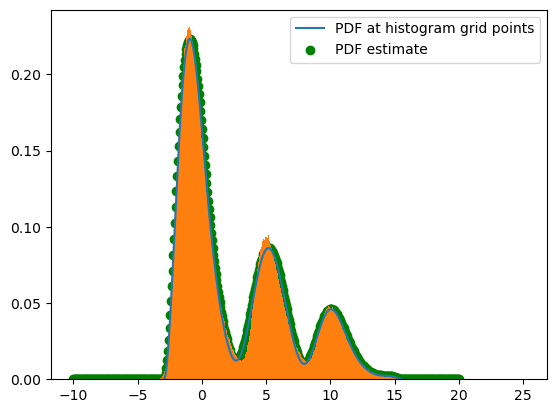

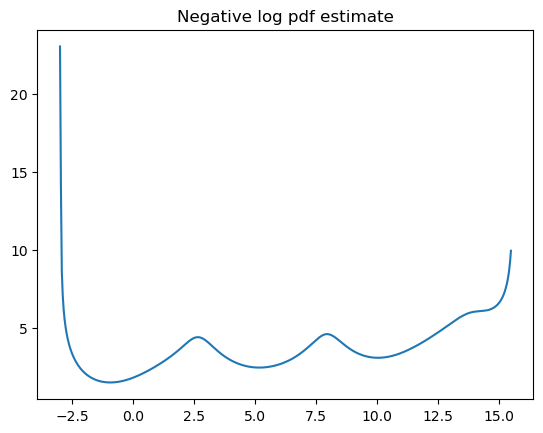

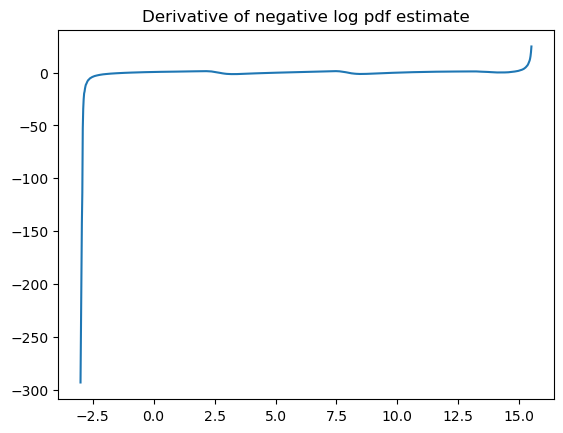

In [14]:
np.random.seed(0)
import matplotlib.pyplot as plt

N = 5_000_000
X = np.random.normal(0,1,N)
Y = X + np.concatenate((np.random.gumbel(-1, 1, 5*N//8),np.random.gumbel(5, 1, N//4), np.random.gumbel(10, 1, N//8))) #random choise of noise distribution

# Solve the problem (deconvolve after histogramming, then produce interpolator)
xg, piN, pmf_cache = estimate_noise_pmf(X, Y)
pmf_cache = finalize_pdf_cache(xg, pmf_cache)

# #Evaluate the PDF anywhere:
grid_vals = pdf(np.linspace(-10, 20, 502), pmf_cache) #502 is arbitrary here

plt.plot(xg, piN, label='PDF at histogram grid points')
plt.scatter(np.linspace(-10, 20, 502), grid_vals, c='g',label='PDF estimate')
plt.hist(np.concatenate((np.random.gumbel(-1, 1, 5*N//8),np.random.gumbel(5, 1, N//4), np.random.gumbel(10, 1, N//8))), bins=1001, density=True)
plt.legend()
plt.show()

plt.figure()
supp = np.linspace(-3, 15.5,1000)
plt.plot(supp, np.array([-logpdf_scalar(x, pmf_cache) for x in supp]))
plt.title("Negative log pdf estimate")
plt.show()

plt.figure()

plt.plot(supp, np.array([-dlogpdf_scalar(x, pmf_cache) for x in supp]))
plt.title("Derivative of negative log pdf estimate")

plt.show()